In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [5]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print("Train:", train.shape)
print("Test:", test.shape)

Train: (750000, 18)
Test: (250000, 17)


In [14]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,750000.0,374999.500000,216506.495284,0.0,187499.75,374999.5,562499.25,749999.0
age,750000.0,40.926395,10.098829,18.0,33.00,39.0,48.00,95.0
balance,750000.0,1204.067397,2836.096759,-8019.0,0.00,634.0,1390.00,99717.0
day,750000.0,16.117209,8.250832,1.0,9.00,17.0,21.00,31.0
duration,750000.0,256.229144,272.555662,1.0,91.00,133.0,361.00,4918.0
campaign,750000.0,2.577008,2.718514,1.0,1.00,2.0,3.00,63.0
pdays,750000.0,22.412733,77.319998,-1.0,-1.00,-1.0,-1.00,871.0
previous,750000.0,0.298545,1.335926,0.0,0.00,0.0,0.00,200.0
y,750000.0,0.120651,0.325721,0.0,0.00,0.0,0.00,1.0


In [15]:
train.describe(include="object").T

,count,unique,top,freq
job,750000,12,management,175541
marital,750000,3,married,480759
education,750000,4,secondary,401683
default,750000,2,no,737151
housing,750000,2,yes,411288
loan,750000,2,no,645023
contact,750000,3,cellular,486655
month,750000,12,may,228411
poutcome,750000,4,unknown,672450


In [16]:
for col in train.columns:
    print(f"{col}: {train[col].nunique()} valores únicos")

id: 750000 valores únicos
age: 78 valores únicos
job: 12 valores únicos
marital: 3 valores únicos
education: 4 valores únicos
default: 2 valores únicos
balance: 8217 valores únicos
housing: 2 valores únicos
loan: 2 valores únicos
contact: 3 valores únicos
day: 31 valores únicos
month: 12 valores únicos
duration: 1760 valores únicos
campaign: 52 valores únicos
pdays: 596 valores únicos
previous: 50 valores únicos
poutcome: 4 valores únicos
y: 2 valores únicos


In [6]:
train.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [7]:
train.tail()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
749995,749995,29,services,single,secondary,no,1282,no,yes,unknown,4,jul,1006,2,-1,0,unknown,1
749996,749996,69,retired,divorced,tertiary,no,631,no,no,cellular,19,aug,87,1,-1,0,unknown,0
749997,749997,50,blue-collar,married,secondary,no,217,yes,no,cellular,17,apr,113,1,-1,0,unknown,0
749998,749998,32,technician,married,secondary,no,-274,no,no,cellular,26,aug,108,6,-1,0,unknown,0
749999,749999,42,technician,married,secondary,no,1559,no,no,cellular,4,aug,143,1,1,7,failure,0


In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   id         750000 non-null  int64
 1   age        750000 non-null  int64
 2   job        750000 non-null  str  
 3   marital    750000 non-null  str  
 4   education  750000 non-null  str  
 5   default    750000 non-null  str  
 6   balance    750000 non-null  int64
 7   housing    750000 non-null  str  
 8   loan       750000 non-null  str  
 9   contact    750000 non-null  str  
 10  day        750000 non-null  int64
 11  month      750000 non-null  str  
 12  duration   750000 non-null  int64
 13  campaign   750000 non-null  int64
 14  pdays      750000 non-null  int64
 15  previous   750000 non-null  int64
 16  poutcome   750000 non-null  str  
 17  y          750000 non-null  int64
dtypes: int64(9), str(9)
memory usage: 103.0 MB


In [9]:
test.isnull().sum()

id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
dtype: int64

In [10]:
train.duplicated().sum()

np.int64(0)

In [11]:
train["id"].duplicated().sum()

np.int64(0)

In [12]:
train["y"].value_counts()

y
0    659512
1     90488
Name: count, dtype: int64

In [13]:
train["y"].value_counts(normalize=True) * 100

y
0    87.934933
1    12.065067
Name: proportion, dtype: float64

## Análisis exploratorio de variables numéricas

In [3]:
numeric_features = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

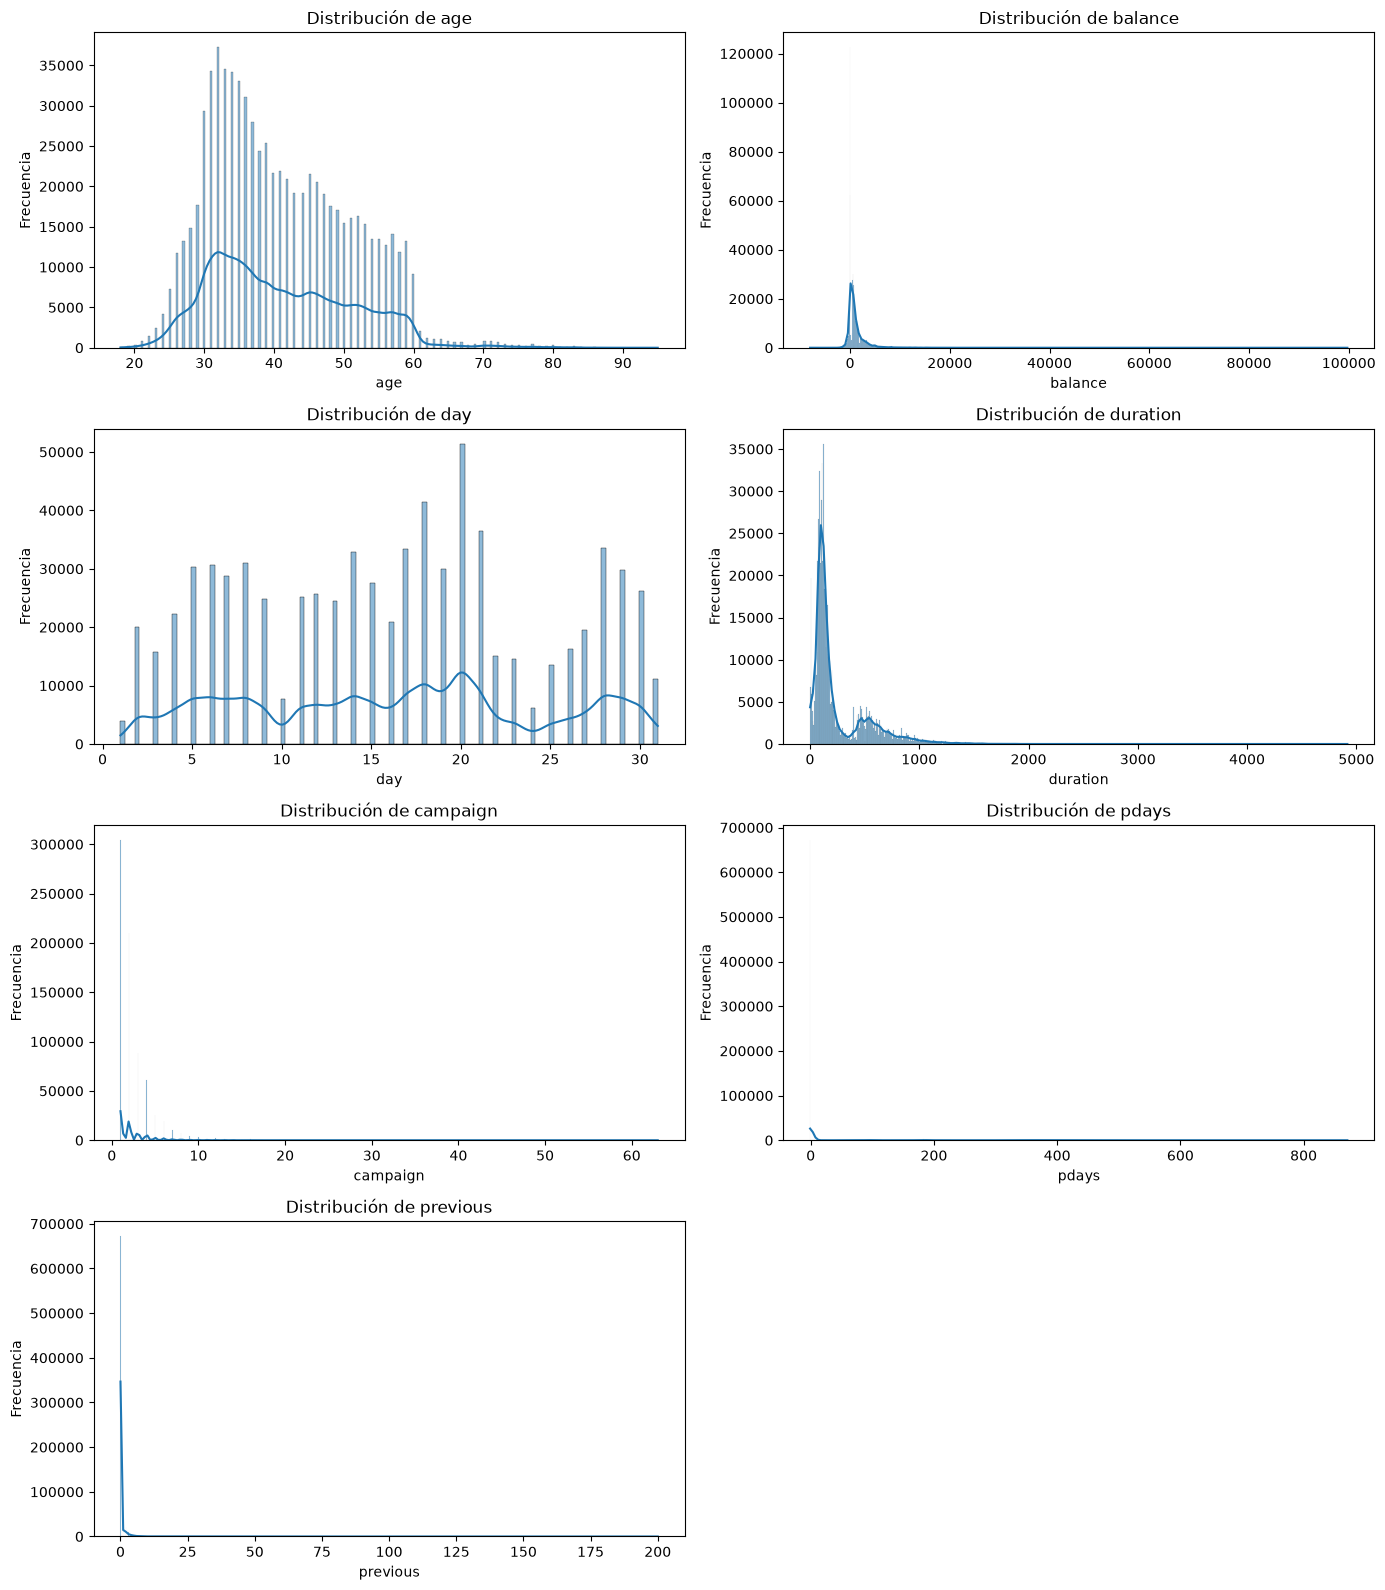

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(data=train, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

# Eliminar el último gráfico vacío
axes[-1].remove()

plt.tight_layout()
plt.show()

In [5]:
## 3. Distribución de la variable objetivo

train["y"].value_counts()

y
0    659512
1     90488
Name: count, dtype: int64

In [6]:
acceptance_rate = train["y"].mean() * 100

print(f"Tasa general de aceptación: {acceptance_rate:.2f}%")

Tasa general de aceptación: 12.07%


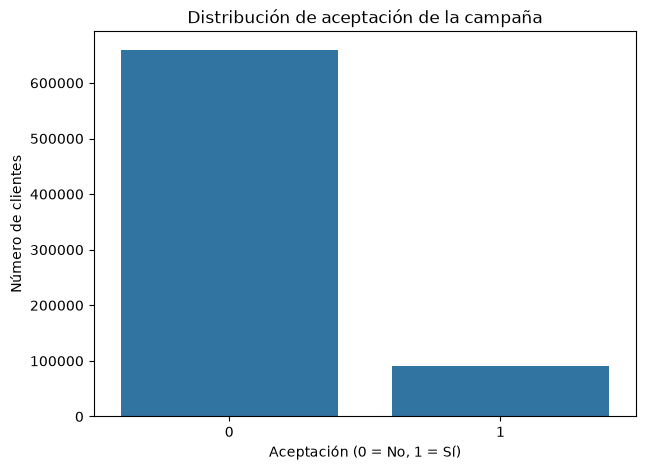

In [7]:
plt.figure(figsize=(7, 5))

sns.countplot(data=train, x="y")

plt.title("Distribución de aceptación de la campaña")
plt.xlabel("Aceptación (0 = No, 1 = Sí)")
plt.ylabel("Número de clientes")

plt.show()

In [8]:
job_acceptance = (
    train.groupby("job")["y"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

job_acceptance["acceptance_rate"] = job_acceptance["mean"] * 100

job_acceptance

,count,mean,acceptance_rate
job,,,
student,11767,0.340784,34.078355
retired,35185,0.246241,24.624130
unemployed,17634,0.179823,17.982307
management,175541,0.150392,15.039222
self-employed,19020,0.129443,12.944269
unknown,2917,0.120672,12.067192
technician,138107,0.118321,11.832130
admin.,81492,0.116453,11.645315
housemaid,15912,0.084653,8.465309


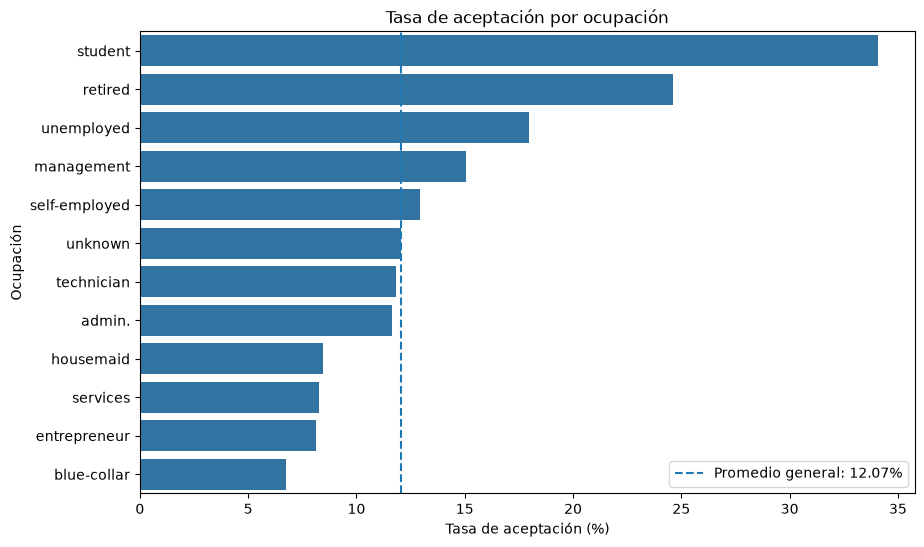

In [9]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=job_acceptance.reset_index(),
    x="acceptance_rate",
    y="job"
)

plt.axvline(
    acceptance_rate,
    linestyle="--",
    label=f"Promedio general: {acceptance_rate:.2f}%"
)

plt.title("Tasa de aceptación por ocupación")
plt.xlabel("Tasa de aceptación (%)")
plt.ylabel("Ocupación")
plt.legend()

plt.show()

In [10]:
train["age_group"] = pd.cut(
    train["age"],
    bins=[17, 29, 39, 49, 59, 69, 100],
    labels=["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]
)

In [11]:
age_acceptance = (
    train.groupby("age_group", observed=False)["y"]
    .agg(["count", "mean"])
)

age_acceptance["acceptance_rate"] = age_acceptance["mean"] * 100

age_acceptance

,count,mean,acceptance_rate
age_group,,,
18-29,74425,0.203802,20.380249
30-39,311404,0.111254,11.125419
40-49,198509,0.091623,9.162305
50-59,142093,0.094199,9.419887
60-69,17785,0.342873,34.287321
70+,5784,0.519364,51.936376


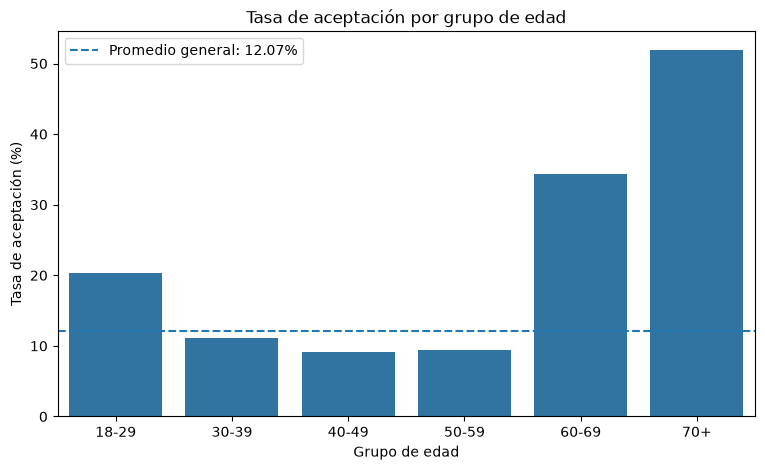

In [12]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=age_acceptance.reset_index(),
    x="age_group",
    y="acceptance_rate"
)

plt.axhline(
    acceptance_rate,
    linestyle="--",
    label=f"Promedio general: {acceptance_rate:.2f}%"
)

plt.title("Tasa de aceptación por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Tasa de aceptación (%)")
plt.legend()

plt.show()

In [13]:
age_job_acceptance = (
    train.groupby(["age_group", "job"], observed=False)["y"]
    .agg(["count", "mean"])
)

age_job_acceptance["acceptance_rate"] = (
    age_job_acceptance["mean"] * 100
)

age_job_acceptance

count      mean  acceptance_rate
age_group job                                           
18-29     admin.        10477  0.161019        16.101938
          blue-collar   15843  0.109449        10.944897
          entrepreneur    929  0.108719        10.871905
          housemaid       459  0.108932        10.893246
          management    12280  0.276303        27.630293
...                       ...       ...              ...
70+       services          5  0.800000        80.000000
          student           0       NaN              NaN
          technician       51  0.529412        52.941176
          unemployed        9  0.444444        44.444444
          unknown          58  0.413793        41.379310

[72 rows x 3 columns]

In [14]:
age_job_pivot = age_job_acceptance["acceptance_rate"].unstack()

age_job_pivot

job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
age_group,,,,,,,,,,,,
18-29,16.101938,10.944897,10.871905,10.893246,27.630293,25.000000,26.467803,12.119097,36.714348,21.435587,25.981308,28.571429
30-39,10.461060,6.389342,8.162003,6.234061,15.383617,11.061947,13.418694,8.240179,24.904540,11.487835,16.733996,10.234542
40-49,10.633828,6.494682,7.479035,7.069864,11.846154,6.589786,8.731689,6.728381,17.948718,9.854114,15.699182,10.794297
50-59,11.202673,5.331378,7.300308,7.505445,11.949468,10.756356,7.290195,7.323018,20.833333,9.847387,17.272249,8.723022
60-69,32.309217,15.802075,24.894515,22.979552,36.237374,38.822202,38.023952,21.818182,100.000000,28.010949,38.235294,24.607330
70+,42.553191,41.176471,42.857143,40.601504,44.444444,52.835993,45.945946,80.000000,NaN,52.941176,44.444444,41.379310


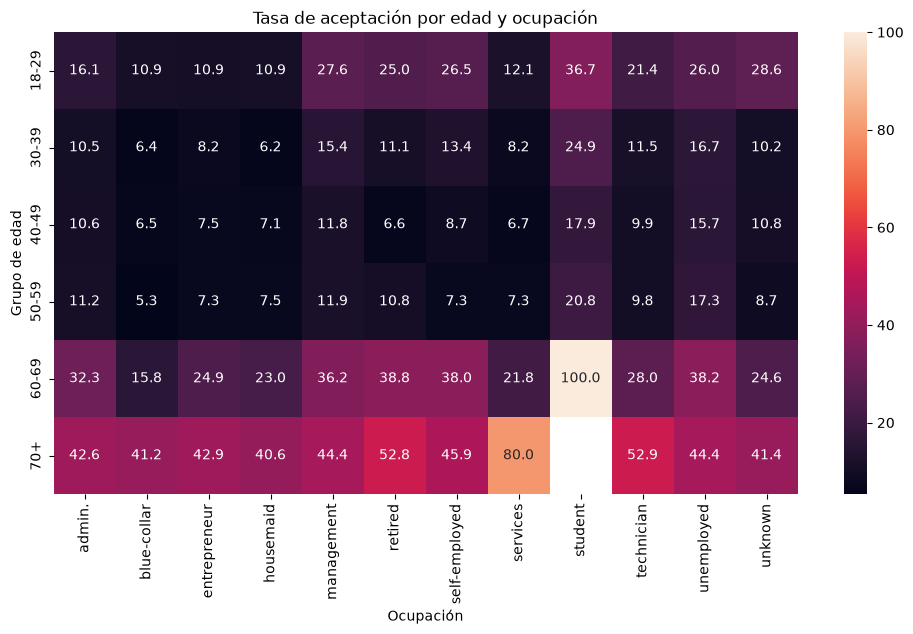

In [15]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    age_job_pivot,
    annot=True,
    fmt=".1f"
)

plt.title("Tasa de aceptación por edad y ocupación")
plt.xlabel("Ocupación")
plt.ylabel("Grupo de edad")

plt.show()

In [16]:
age_job_counts = age_job_acceptance["count"].unstack()

age_job_counts

job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
age_group,,,,,,,,,,,,
18-29,10477,15843,929,459,12280,36,2112,8598,9228,12218,2140,105
30-39,34117,69882,6469,3529,84772,226,7810,28179,2357,67158,6436,469
40-49,22372,54152,5843,4795,44200,1214,5188,17716,156,36878,5013,982
50-59,13470,29317,4219,5969,31742,18761,3539,9436,24,20706,3798,1112
60-69,1009,1253,237,1027,2376,9747,334,275,2,1096,238,191
70+,47,51,21,133,171,5201,37,5,0,51,9,58


In [17]:
train["duration"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]
)

count    750000.000000
mean        256.229144
std         272.555662
min           1.000000
25%          91.000000
50%         133.000000
75%         361.000000
90%         645.000000
95%         829.000000
max        4918.000000
Name: duration, dtype: float64

In [18]:
train["duration_group"] = pd.cut(
    train["duration"],
    bins=[0, 90, 133, 361, 645, float("inf")],
    labels=[
        "0-90",
        "91-133",
        "134-361",
        "362-645",
        "646+"
    ]
)

In [19]:
duration_acceptance = (
    train.groupby("duration_group", observed=False)["y"]
    .agg(["count", "mean"])
)

duration_acceptance["acceptance_rate"] = (
    duration_acceptance["mean"] * 100
)

duration_acceptance

,count,mean,acceptance_rate
duration_group,,,
0-90,185621,0.001783,0.178320
91-133,190569,0.009629,0.962906
134-361,186473,0.110091,11.009101
362-645,112545,0.243280,24.328047
646+,74792,0.540339,54.033854


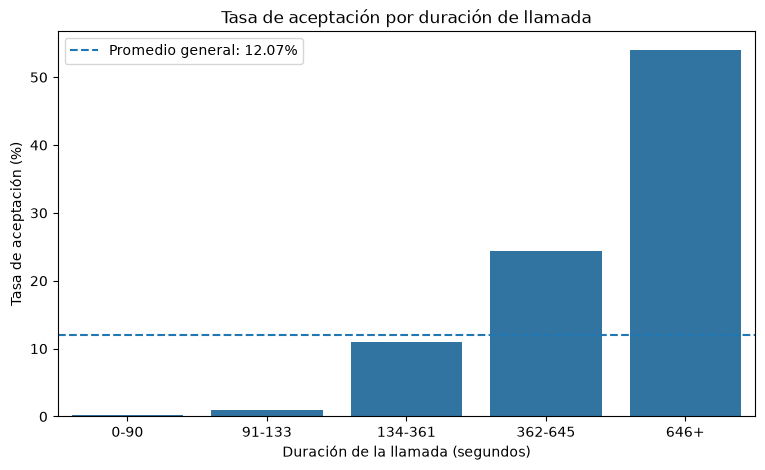

In [20]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=duration_acceptance.reset_index(),
    x="duration_group",
    y="acceptance_rate"
)

plt.axhline(
    acceptance_rate,
    linestyle="--",
    label=f"Promedio general: {acceptance_rate:.2f}%"
)

plt.title("Tasa de aceptación por duración de llamada")
plt.xlabel("Duración de la llamada (segundos)")
plt.ylabel("Tasa de aceptación (%)")
plt.legend()

plt.show()

In [21]:
train["campaign"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

count    750000.000000
mean          2.577008
std           2.718514
min           1.000000
50%           2.000000
75%           3.000000
90%           5.000000
95%           7.000000
99%          14.000000
max          63.000000
Name: campaign, dtype: float64

In [22]:
train["campaign_group"] = pd.cut(
    train["campaign"],
    bins=[0, 1, 2, 3, 5, 10, float("inf")],
    labels=[
        "1",
        "2",
        "3",
        "4-5",
        "6-10",
        "11+"
    ]
)

In [23]:
campaign_acceptance = (
    train.groupby("campaign_group", observed=False)["y"]
    .agg(["count", "mean"])
)

campaign_acceptance["acceptance_rate"] = (
    campaign_acceptance["mean"] * 100
)

campaign_acceptance

,count,mean,acceptance_rate
campaign_group,,,
1,304481,0.152831,15.283055
2,209834,0.113647,11.364698
3,88683,0.105635,10.563468
4-5,86622,0.082335,8.233474
6-10,45335,0.065931,6.593140
11+,15045,0.041077,4.107677


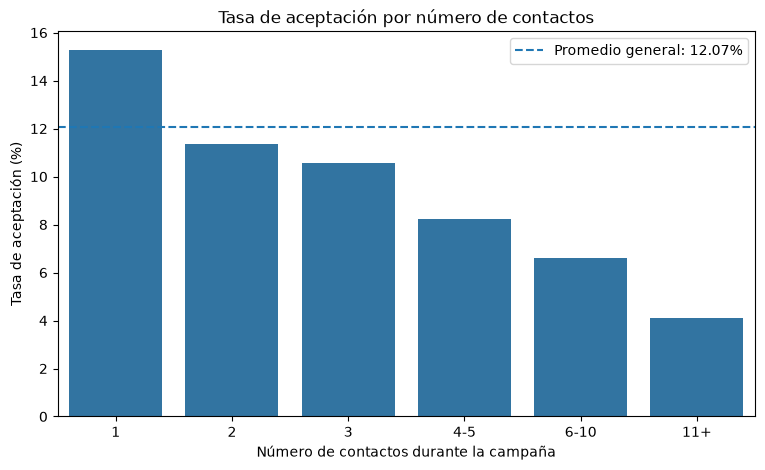

In [24]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=campaign_acceptance.reset_index(),
    x="campaign_group",
    y="acceptance_rate"
)

plt.axhline(
    acceptance_rate,
    linestyle="--",
    label=f"Promedio general: {acceptance_rate:.2f}%"
)

plt.title("Tasa de aceptación por número de contactos")
plt.xlabel("Número de contactos durante la campaña")
plt.ylabel("Tasa de aceptación (%)")
plt.legend()

plt.show()

In [25]:
poutcome_acceptance = (
    train.groupby("poutcome")["y"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

poutcome_acceptance["acceptance_rate"] = (
    poutcome_acceptance["mean"] * 100
)

poutcome_acceptance

,count,mean,acceptance_rate
poutcome,,,
success,17691,0.764004,76.400430
other,14744,0.166848,16.684753
failure,45115,0.132794,13.279397
unknown,672450,0.101898,10.189754


In [26]:
train["previously_contacted"] = train["previous"] > 0

In [27]:
previous_contact_acceptance = (
    train.groupby("previously_contacted")["y"]
    .agg(["count", "mean"])
)

previous_contact_acceptance["acceptance_rate"] = (
    previous_contact_acceptance["mean"] * 100
)

previous_contact_acceptance

,count,mean,acceptance_rate
previously_contacted,,,
False,672431,0.101899,10.189893
True,77569,0.283206,28.320592


In [28]:
train["previously_contacted"] = train["previous"] > 0

In [29]:
education_acceptance = (
    train.groupby("education")["y"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

education_acceptance["acceptance_rate"] = (
    education_acceptance["mean"] * 100
)

education_acceptance

,count,mean,acceptance_rate
education,,,
tertiary,227508,0.162649,16.264923
unknown,21299,0.133387,13.338654
secondary,401683,0.105491,10.549115
primary,99510,0.083097,8.309718


In [30]:
marital_acceptance = (
    train.groupby("marital")["y"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

marital_acceptance["acceptance_rate"] = (
    marital_acceptance["mean"] * 100
)

marital_acceptance

,count,mean,acceptance_rate
marital,,,
single,194834,0.170453,17.045280
divorced,74407,0.111576,11.157552
married,480759,0.101872,10.187225


In [31]:
housing_acceptance = (
    train.groupby("housing")["y"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

housing_acceptance["acceptance_rate"] = (
    housing_acceptance["mean"] * 100
)

housing_acceptance

,count,mean,acceptance_rate
housing,,,
no,338712,0.175778,17.577765
yes,411288,0.075251,7.525141


In [32]:
loan_acceptance = (
    train.groupby("loan")["y"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

loan_acceptance["acceptance_rate"] = (
    loan_acceptance["mean"] * 100
)

loan_acceptance

,count,mean,acceptance_rate
loan,,,
no,645023,0.131378,13.137826
yes,104977,0.054736,5.473580


In [33]:
default_acceptance = (
    train.groupby("default")["y"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

default_acceptance["acceptance_rate"] = (
    default_acceptance["mean"] * 100
)

default_acceptance

,count,mean,acceptance_rate
default,,,
no,737151,0.121947,12.194652
yes,12849,0.046307,4.630711


In [34]:
train["balance"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]
)

count    750000.000000
mean       1204.067397
std        2836.096759
min       -8019.000000
25%           0.000000
50%         634.000000
75%        1390.000000
90%        3025.000000
95%        4493.000000
max       99717.000000
Name: balance, dtype: float64

In [35]:
train["balance_group"] = pd.cut(
    train["balance"],
    bins=[-np.inf, 0, 500, 1000, 2000, 5000, np.inf],
    labels=[
        "<=0",
        "1-500",
        "501-1000",
        "1001-2000",
        "2001-5000",
        "5000+"
    ]
)

In [36]:
balance_acceptance = (
    train.groupby("balance_group", observed=False)["y"]
    .agg(["count", "mean"])
)

balance_acceptance["acceptance_rate"] = (
    balance_acceptance["mean"] * 100
)

balance_acceptance

,count,mean,acceptance_rate
balance_group,,,
<=0,197804,0.035272,3.527229
1-500,113809,0.099069,9.906949
501-1000,182560,0.131880,13.187993
1001-2000,126491,0.153782,15.378169
2001-5000,100289,0.203971,20.397053
5000+,29047,0.284091,28.409130


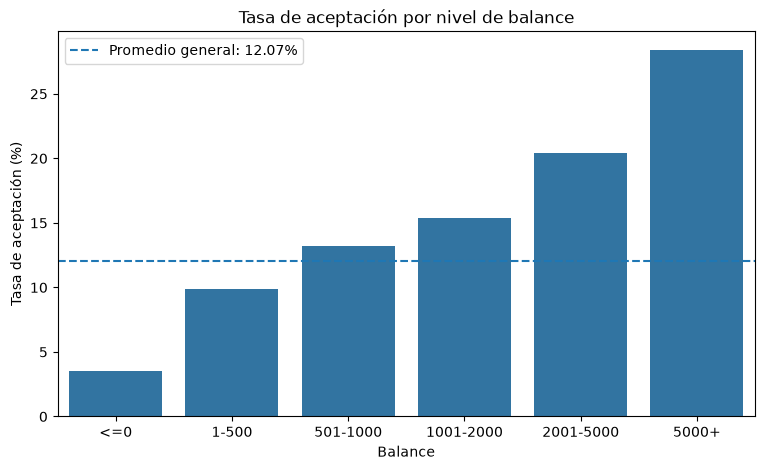

In [37]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=balance_acceptance.reset_index(),
    x="balance_group",
    y="acceptance_rate"
)

plt.axhline(
    acceptance_rate,
    linestyle="--",
    label=f"Promedio general: {acceptance_rate:.2f}%"
)

plt.title("Tasa de aceptación por nivel de balance")
plt.xlabel("Balance")
plt.ylabel("Tasa de aceptación (%)")
plt.legend()

plt.show()

In [38]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   id                    750000 non-null  int64   
 1   age                   750000 non-null  int64   
 2   job                   750000 non-null  str     
 3   marital               750000 non-null  str     
 4   education             750000 non-null  str     
 5   default               750000 non-null  str     
 6   balance               750000 non-null  int64   
 7   housing               750000 non-null  str     
 8   loan                  750000 non-null  str     
 9   contact               750000 non-null  str     
 10  day                   750000 non-null  int64   
 11  month                 750000 non-null  str     
 12  duration              750000 non-null  int64   
 13  campaign              750000 non-null  int64   
 14  pdays                 750000 non-null  int64   

In [39]:
train.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,age_group,duration_group,campaign_group,previously_contacted,balance_group
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0,40-49,91-133,3,False,1-500
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0,30-39,134-361,1,False,501-1000
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0,30-39,91-133,2,False,501-1000
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0,18-29,0-90,2,False,1-500
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1,18-29,646+,1,False,501-1000


In [40]:
train.isna().sum()

id                      0
age                     0
job                     0
marital                 0
education               0
default                 0
balance                 0
housing                 0
loan                    0
contact                 0
day                     0
month                   0
duration                0
campaign                0
pdays                   0
previous                0
poutcome                0
y                       0
age_group               0
duration_group          0
campaign_group          0
previously_contacted    0
balance_group           0
dtype: int64

In [41]:
train.duplicated().sum()

np.int64(0)

In [42]:
for col in train.select_dtypes(include=["str"]).columns:
    print(f"\n{col}")
    print(train[col].value_counts())


job
job
management       175541
blue-collar      170498
technician       138107
admin.            81492
services          64209
retired           35185
self-employed     19020
entrepreneur      17718
unemployed        17634
housemaid         15912
student           11767
unknown            2917
Name: count, dtype: int64

marital
marital
married     480759
single      194834
divorced     74407
Name: count, dtype: int64

education
education
secondary    401683
tertiary     227508
primary       99510
unknown       21299
Name: count, dtype: int64

default
default
no     737151
yes     12849
Name: count, dtype: int64

housing
housing
yes    411288
no     338712
Name: count, dtype: int64

loan
loan
no     645023
yes    104977
Name: count, dtype: int64

contact
contact
cellular     486655
unknown      231627
telephone     31718
Name: count, dtype: int64

month
month
may    228411
aug    128859
jul    110647
jun     93670
nov     66062
apr     41319
feb     37611
jan     18937
oct      9204
s

In [43]:
numeric_cols = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "y"
]

train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,750000.0,40.926395,10.098829,18.0,33.0,39.0,48.0,95.0
balance,750000.0,1204.067397,2836.096759,-8019.0,0.0,634.0,1390.0,99717.0
day,750000.0,16.117209,8.250832,1.0,9.0,17.0,21.0,31.0
duration,750000.0,256.229144,272.555662,1.0,91.0,133.0,361.0,4918.0
campaign,750000.0,2.577008,2.718514,1.0,1.0,2.0,3.0,63.0
pdays,750000.0,22.412733,77.319998,-1.0,-1.0,-1.0,-1.0,871.0
previous,750000.0,0.298545,1.335926,0.0,0.0,0.0,0.0,200.0
y,750000.0,0.120651,0.325721,0.0,0.0,0.0,0.0,1.0


In [44]:
for col in numeric_cols:
    print(f"\n--- {col} ---")
    print("min:", train[col].min())
    print("max:", train[col].max())
    print("unique:", train[col].nunique())


--- age ---
min: 18
max: 95
unique: 78

--- balance ---
min: -8019
max: 99717
unique: 8217

--- day ---
min: 1
max: 31
unique: 31

--- duration ---
min: 1
max: 4918
unique: 1760

--- campaign ---
min: 1
max: 63
unique: 52

--- pdays ---
min: -1
max: 871
unique: 596

--- previous ---
min: 0
max: 200
unique: 50

--- y ---
min: 0
max: 1
unique: 2
